# 8. Figuras do relatório — leitura didática do modelo integrado

Este notebook não reestima o modelo. Ele consome o painel consolidado e as tabelas
produzidas pelo notebook 07 para explicar, em ordem causal, as cinco camadas:

1. carga residual, preço e captura;
2. clearing locacional com reservatório e curtailment explícitos;
3. laboratório finito de incumbente e entrante;
4. benchmark privado estático e ótimo social;
5. MFG dinâmico com Bellman, política, forward e ponto fixo.

CMO, PLD e $\lambda$ permanecem objetos distintos. O dual do balanço escrito como
`carga − geração = 0` é o próprio preço-sombra. Resultados com `DYN_TAU_RS>0` são
identificados como MFG entrópico regularizado, não como o jogo discreto exato.


## 0. Setup — dados, tabelas e estilo

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.titleweight": "bold",
    "axes.spines.right": False, "axes.spines.top": False,
    "font.size": 10,
})

# Ordem CANÔNICA dos subsistemas: [SE, S, NE, N]
SUBSYS_ORDER = ["SE", "S", "NE", "N"]
SUB_LABEL = {"N": "Norte", "NE": "Nordeste", "SE": "Sudeste/CO", "S": "Sul"}
SUB_COLOR = {"N": "#1f77b4", "NE": "#d62728", "SE": "#2ca02c", "S": "#9467bd"}


def find_project_root(marker: str = "validate_model") -> Path:
    cur = Path.cwd().resolve()
    for cand in [cur, *cur.parents]:
        if (cand / marker).exists():
            return cand
    return cur

ROOT = find_project_root()
OUT = ROOT / "outputs"
FIG_DIR = OUT / "figures"; TAB_DIR = OUT / "tables"; CACHE = OUT / "cache"
FIG_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_parquet(CACHE / "panel_hourly_v4_consolidated.parquet")
panel["din_instante"] = pd.to_datetime(panel["din_instante"])
if "L_res" not in panel.columns:
    panel["L_res"] = panel["L"] - panel["G_solar_obs"] - panel["G_wind_obs"]

def load_tab(name):
    p = TAB_DIR / name
    return pd.read_csv(p) if p.exists() else None

per = f'{panel["din_instante"].min():%Y-%m-%d} a {panel["din_instante"].max():%Y-%m-%d}'
print(f"Painel: {len(panel):,} linhas | período {per}")
print("Subsistemas:", sorted(panel["id_subsistema"].unique()))
print("Tabelas MFG disponíveis:", sorted(p.name for p in TAB_DIR.glob("*.csv")))


Painel: 35,040 linhas | período 2025-01-01 a 2025-12-31
Subsistemas: ['N', 'NE', 'S', 'SE']
Tabelas MFG disponíveis: ['capacidade_proxy_p99.csv', 'dispatch_quadratic_terms_sensitivity.csv', 'dynamic_mfg_convergence.csv', 'dynamic_mfg_distribution.csv', 'dynamic_mfg_modal_paths.csv', 'dynamic_mfg_path.csv', 'dynamic_mfg_policy.csv', 'dynamic_mfg_policy_summary.csv', 'entry_wedge_calibration_path.csv', 'finite_two_player_sensitivity.csv', 'fixed_budget_capacity.csv', 'gamma_r_sensitivity.csv', 'hydrology_sensitivity.csv', 'individual_agent_paths.csv', 'individual_policy_summary.csv', 'lambda_prime_sensitivity.csv', 'lambda_prime_south_step_sensitivity.csv', 'mfg_clearing_diagnostics.csv', 'mfg_convergence_history.csv', 'mfg_locational_equilibrium.csv', 'private_vs_social_capacity.csv', 'representative_days.csv', 'representative_days_homogeneity.csv', 'representative_days_model_selection.csv', 'reservoir_audit.csv', 'reservoir_state_path.csv', 'spill_diagnostic_by_region.csv', 'water_valu

## 1. Preço × carga residual — o mecanismo empírico da canibalização

O motor econômico do artigo é simples: o preço de curto prazo **sobe com a carga
residual** (carga menos solar menos eólica). Quando a solar cresce, ela derruba a
carga residual justamente nas horas em que gera — e, com isso, o próprio preço que
captura. A figura mostra a relação `CMO_obs × carga residual` por subsistema, com
o coeficiente de correlação de Pearson.

> **O caso do Nordeste é o mais interessante** (como notado na revisão): a
> correlação é fraca/negativa. No NE, eólica + solar chegam a exceder a carga em
> muitas horas (carga residual frequentemente negativa), e o preço local se
> descola da carga residual local — o intercâmbio e o excedente renovável passam a
> mandar na formação de preço. Isso antecipa por que o NE é o subsistema onde a
> canibalização e o congestionamento aparecem primeiro. *(Apoia a §2 e a §3 do
> relatório.)*

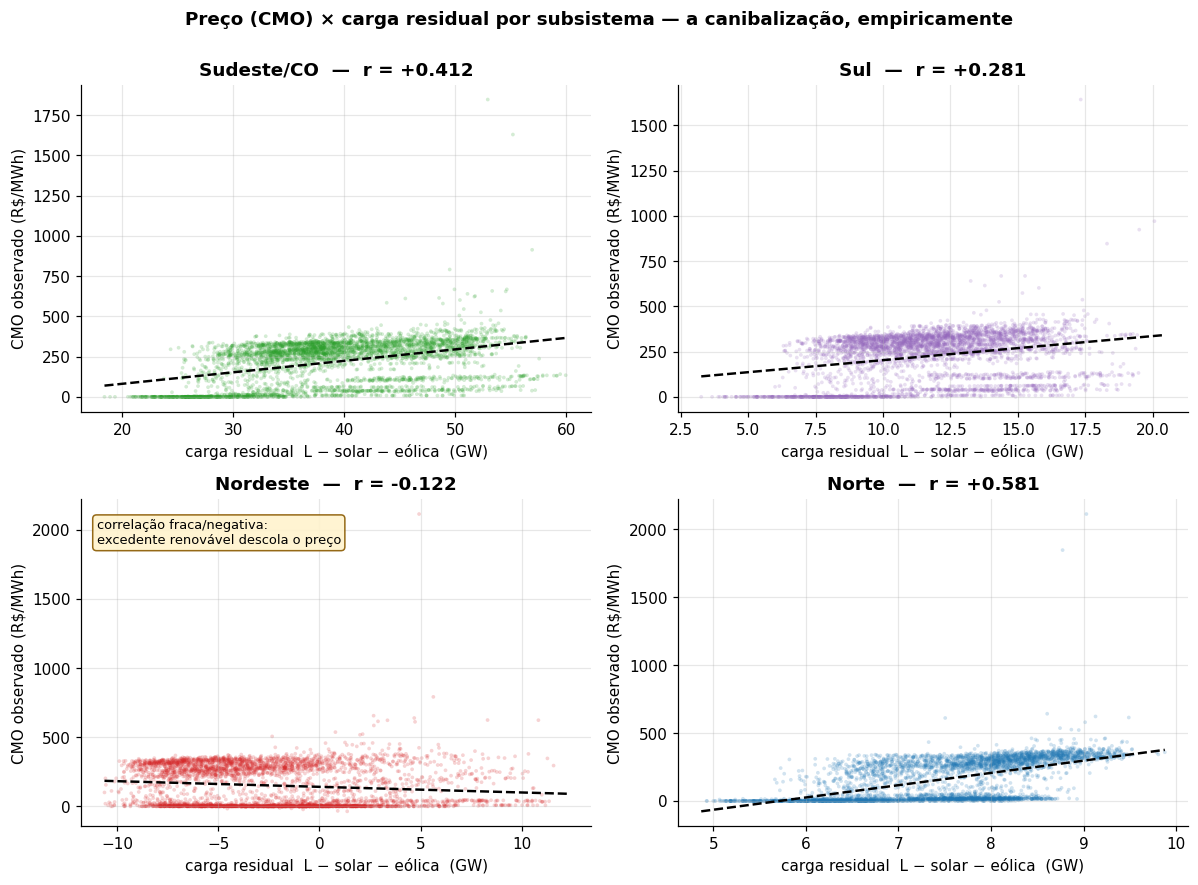

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
rng = np.random.default_rng(42)
for ax, s in zip(axes.ravel(), SUBSYS_ORDER):
    g = panel[panel["id_subsistema"] == s]
    x = g["L_res"].to_numpy(float); y = g["CMO_obs"].to_numpy(float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    r = np.corrcoef(x, y)[0, 1] if len(x) > 2 else np.nan
    idx = rng.choice(len(x), size=min(4000, len(x)), replace=False)
    ax.scatter(x[idx] / 1e3, y[idx], s=6, alpha=0.20, color=SUB_COLOR[s], edgecolors="none")
    if len(x) > 2:
        b1, b0 = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs / 1e3, b0 + b1 * xs, color="black", lw=1.6, ls="--")
    ax.set_title(f"{SUB_LABEL[s]}  —  r = {r:+.3f}")
    ax.set_xlabel("carga residual  L − solar − eólica  (GW)")
    ax.set_ylabel("CMO observado (R$/MWh)")
    ax.grid(alpha=0.3)
    if s == "NE":
        ax.text(0.03, 0.94, "correlação fraca/negativa:\nexcedente renovável descola o preço",
                transform=ax.transAxes, fontsize=8.5, va="top",
                bbox=dict(boxstyle="round", fc="#fff3cd", ec="#8a5a00", alpha=0.9))
fig.suptitle("Preço (CMO) × carga residual por subsistema — a canibalização, empiricamente",
             fontweight="bold", y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "rel_cmo_vs_carga_residual.png", bbox_inches="tight")
plt.show()


## 2. Perfil horário do CMO — distribuição por box-plot

Cada hora reúne todos os dias observados e mostra mediana, intervalo interquartil e
whiskers; outliers individuais são omitidos apenas para legibilidade. Assim, a
dispersão deixa de ser resumida por uma linha média ± desvio-padrão e passa a expor
assimetria e caudas da distribuição. *(Apoia a seção "Carga líquida, carga residual
e rampa" do `report_v2.typ`; implementação: esta célula.)*

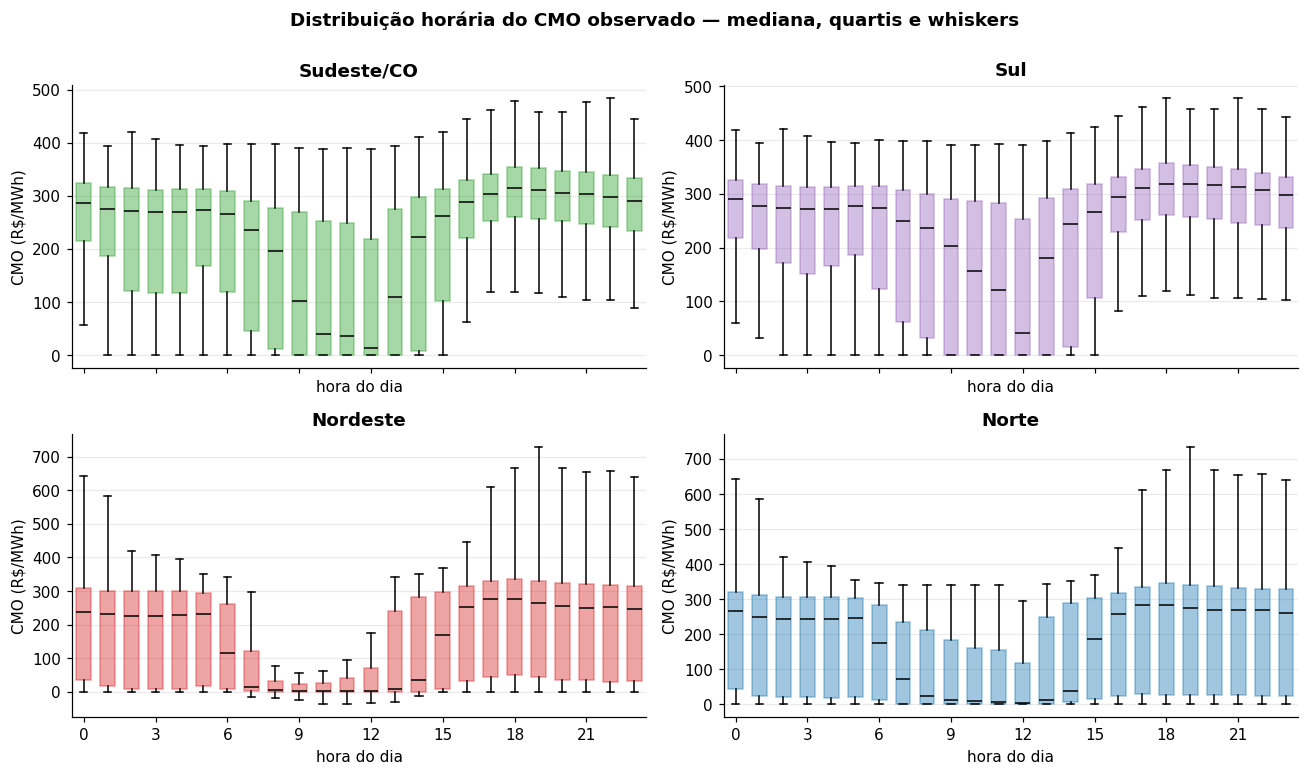

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, s in zip(axes.ravel(), SUBSYS_ORDER):
    sub = panel[panel["id_subsistema"] == s]
    values = [pd.to_numeric(sub.loc[sub["hora"] == h, "CMO_obs"], errors="coerce").dropna().to_numpy()
              for h in range(24)]
    bp = ax.boxplot(values, positions=range(24), widths=0.62, showfliers=False,
                    patch_artist=True, medianprops={"color": "black", "lw": 1.0})
    for box in bp["boxes"]:
        box.set(facecolor=SUB_COLOR[s], alpha=0.42, edgecolor=SUB_COLOR[s])
    ax.set_title(SUB_LABEL[s]); ax.grid(axis="y", alpha=0.25)
    ax.set_xlabel("hora do dia"); ax.set_ylabel("CMO (R$/MWh)")
    ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels(range(0, 24, 3))
fig.suptitle("Distribuição horária do CMO observado — mediana, quartis e whiskers",
             fontweight="bold", y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "rel_cmo_perfil_horario_boxplot.png", bbox_inches="tight")
plt.show()


## 3. Curva do pato — carga, carga líquida e carga residual

O mesmo diagnóstico é mostrado para Norte, Nordeste, Sudeste/CO e Sul: **carga**
(L), **carga líquida de solar** (L − solar) e **carga residual**
(L − solar − eólica). Isso evita extrapolar o formato do Sudeste/CO às demais
regiões. *(Apoia a seção "Carga líquida, carga residual e rampa" do
`report_v2.typ`; implementação: esta célula.)*

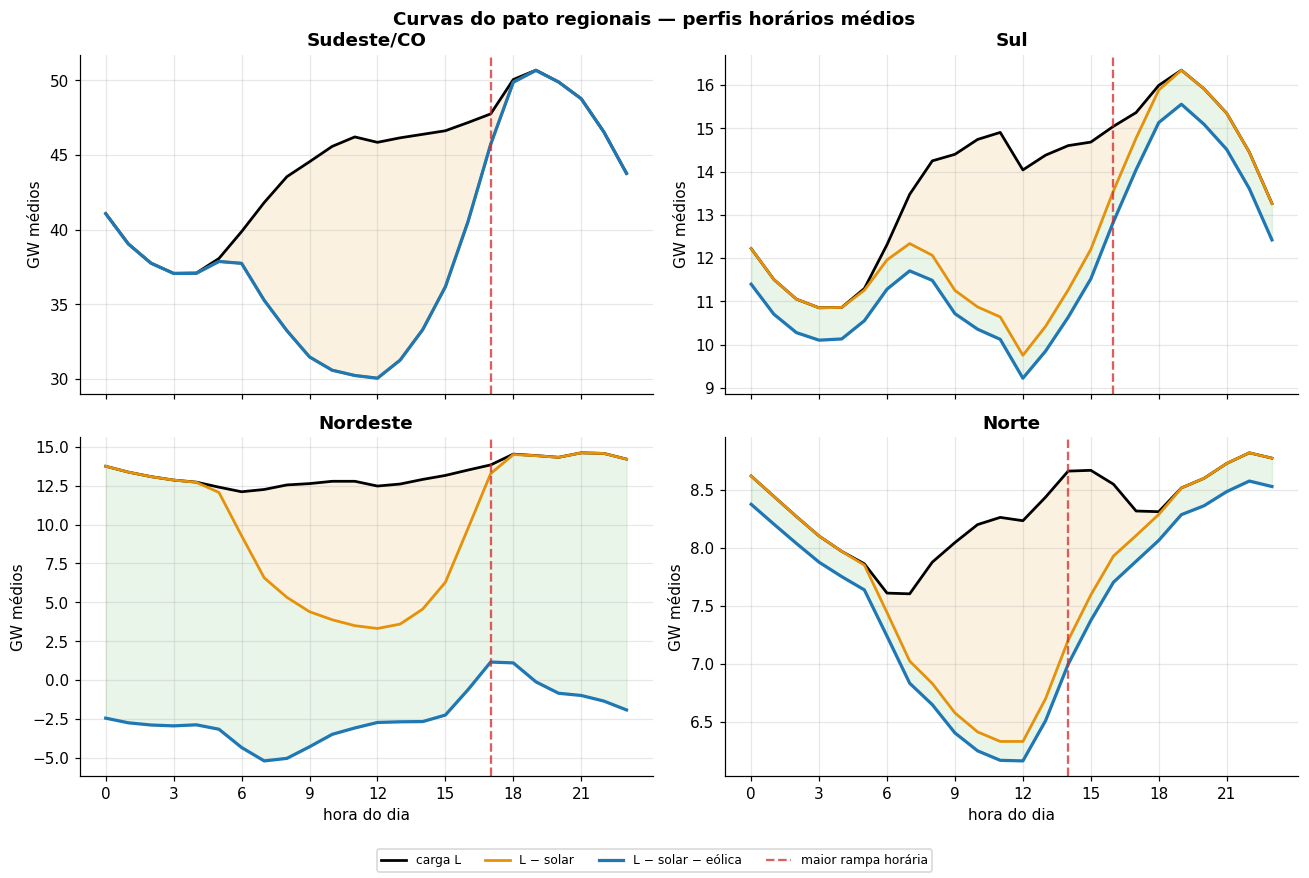

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
h = np.arange(24)
for ax, s in zip(axes.ravel(), SUBSYS_ORDER):
    g = panel[panel["id_subsistema"] == s]
    by_h = g.groupby("hora").agg(L=("L", "mean"), solar=("G_solar_obs", "mean"),
                                 wind=("G_wind_obs", "mean")).reindex(range(24))
    L = by_h["L"] / 1e3
    net = (by_h["L"] - by_h["solar"]) / 1e3
    res = (by_h["L"] - by_h["solar"] - by_h["wind"]) / 1e3
    ax.plot(h, L, lw=1.8, color="black", label="carga L")
    ax.plot(h, net, lw=1.8, color="#e6910a", label="L − solar")
    ax.plot(h, res, lw=2.1, color="#1f77b4", label="L − solar − eólica")
    ax.fill_between(h, res, net, color="#2ca02c", alpha=0.10)
    ax.fill_between(h, net, L, color="#e6910a", alpha=0.12)
    ramp = np.diff(res.to_numpy())
    h_ramp = int(np.nanargmax(ramp) + 1)
    ax.axvline(h_ramp, color="#d62728", ls="--", alpha=0.75,
               label="maior rampa horária")
    ax.set_title(SUB_LABEL[s]); ax.set_ylabel("GW médios")
    ax.set_xticks(range(0, 24, 3)); ax.grid(alpha=0.3)
axes[1, 0].set_xlabel("hora do dia"); axes[1, 1].set_xlabel("hora do dia")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8)
fig.suptitle("Curvas do pato regionais — perfis horários médios", fontweight="bold")
fig.tight_layout()
fig.subplots_adjust(bottom=0.11, top=0.93)
fig.savefig(FIG_DIR / "rel_curva_pato.png", bbox_inches="tight")
plt.show()


## 4. Fatores de captura — solar canibaliza, eólica não

Fator de captura de uma fonte = preço médio *ponderado pela sua geração* dividido
pelo preço médio simples. Abaixo de 1 significa que a fonte vende mais barato que a
média do mercado. Usando o **CMO observado** (lembrando: CMO é custo, não PLD), a
**solar captura abaixo de 1 em todos os subsistemas** (canibalização), enquanto a
**eólica captura em torno de 1 ou acima** — ela gera mais em horas de maior valor.
*(Apoia a §"Fator de captura e canibalização".)*

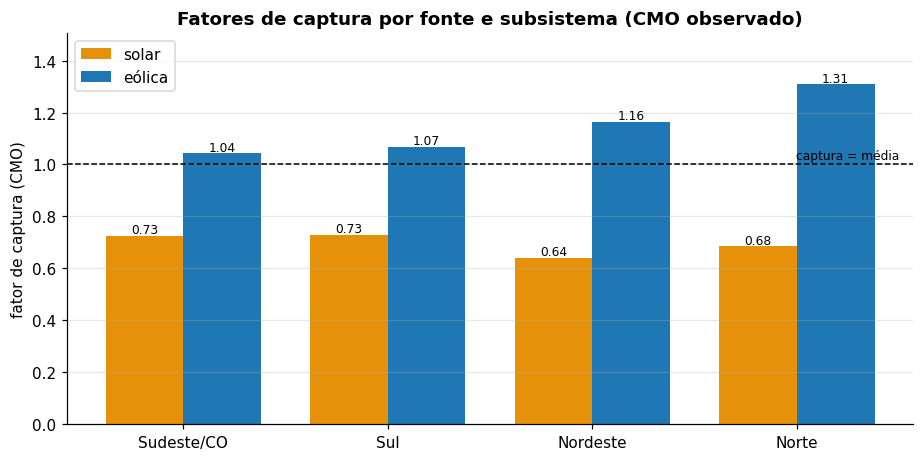

     solar  eolica
loc               
SE   0.725   1.044
S    0.729   1.067
NE   0.640   1.165
N    0.684   1.309


In [5]:
def capture_factor(df, gcol, pcol="CMO_obs"):
    p = pd.to_numeric(df[pcol], errors="coerce").to_numpy(float)
    gg = pd.to_numeric(df[gcol], errors="coerce").to_numpy(float)
    ok = np.isfinite(p) & np.isfinite(gg) & (gg >= 0)
    p, gg = p[ok], gg[ok]
    if gg.sum() <= 0 or p.mean() == 0:
        return np.nan
    return (p * gg).sum() / gg.sum() / p.mean()

rows = []
for s in SUBSYS_ORDER:
    g = panel[panel["id_subsistema"] == s]
    rows.append({"loc": s, "solar": capture_factor(g, "G_solar_obs"),
                 "eolica": capture_factor(g, "G_wind_obs")})
cap = pd.DataFrame(rows).set_index("loc").reindex(SUBSYS_ORDER)

fig, ax = plt.subplots(figsize=(8.5, 4.3))
idx = np.arange(len(cap)); w = 0.38
ax.bar(idx - w / 2, cap["solar"], w, label="solar", color="#e6910a")
ax.bar(idx + w / 2, cap["eolica"], w, label="eólica", color="#1f77b4")
ax.axhline(1.0, color="black", lw=1, ls="--")
ax.text(len(cap) - 0.5, 1.01, "captura = média", fontsize=8, ha="right", va="bottom")
for k, s in enumerate(cap.index):
    ax.text(k - w / 2, cap["solar"][s] + 0.01, f'{cap["solar"][s]:.2f}', ha="center", fontsize=8)
    ax.text(k + w / 2, cap["eolica"][s] + 0.01, f'{cap["eolica"][s]:.2f}', ha="center", fontsize=8)
ax.set_xticks(idx); ax.set_xticklabels([SUB_LABEL[s] for s in cap.index])
ax.set_ylabel("fator de captura (CMO)"); ax.set_ylim(0, max(1.5, cap.max().max() * 1.15))
ax.set_title("Fatores de captura por fonte e subsistema (CMO observado)")
ax.grid(axis="y", alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "rel_fatores_captura.png", bbox_inches="tight")
plt.show()
print(cap.round(3).to_string())


## 5. Estado do reservatório — a ligação intertemporal

O estoque conecta horas: turbinar agora reduz a água disponível depois. Para cada
medoide, a condição cíclica $S_{24}=S_0$ impede que o despacho use gratuitamente o
estoque inicial. A figura confronta estoque, afluência, turbinamento e vertimento e
funciona também como auditoria da equação de movimento.


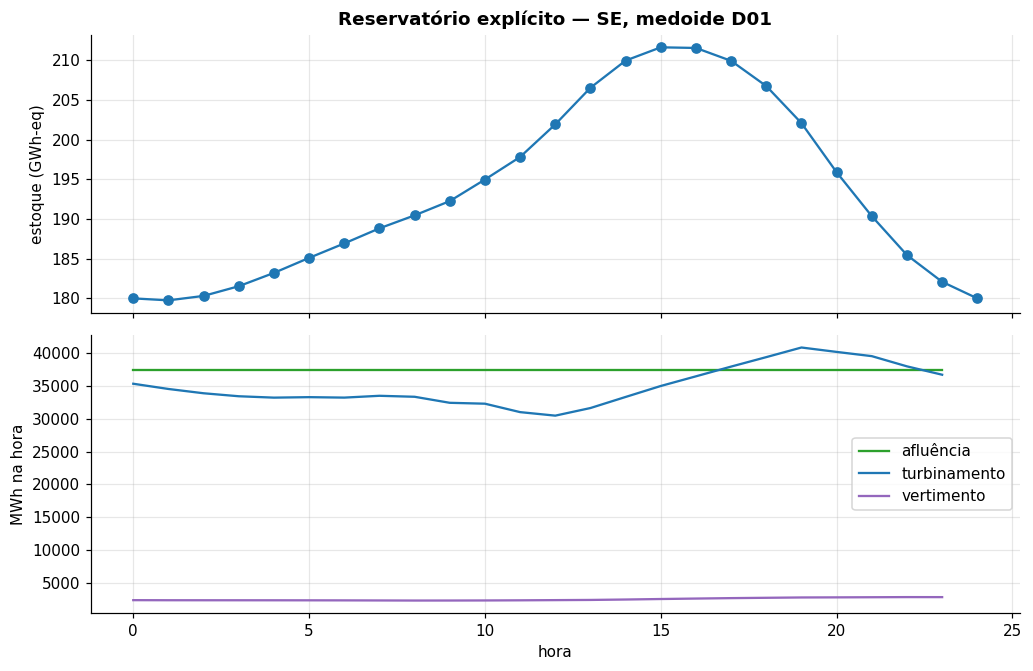

In [6]:
reservoir = load_tab("reservoir_state_path.csv")
if reservoir is None or reservoir.empty:
    print("reservoir_state_path.csv não encontrado — rode o notebook 07.")
else:
    block = reservoir["block"].iloc[0]
    sample = reservoir[(reservoir["loc"] == "SE") & (reservoir["block"] == block)]
    fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True)
    axes[0].plot(sample["hour"], sample["storage_MWh"] / 1000,
                 marker="o", color="#1f77b4")
    axes[0].set_ylabel("estoque (GWh-eq)")
    axes[0].set_title(f"Reservatório explícito — SE, medoide {block}")
    axes[0].grid(alpha=0.3)
    axes[1].plot(sample["hour"], sample["inflow_MWh"], label="afluência", color="#2ca02c")
    axes[1].plot(sample["hour"], sample["hydro_MWh"], label="turbinamento", color="#1f77b4")
    axes[1].plot(sample["hour"], sample["spill_MWh"], label="vertimento", color="#9467bd")
    axes[1].set_xlabel("hora"); axes[1].set_ylabel("MWh na hora")
    axes[1].grid(alpha=0.3); axes[1].legend()
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_reservoir_state.png", bbox_inches="tight")
    plt.show()


## 6. Sensibilidade hidrológica — o mesmo sistema sob afluência seca, base e úmida

Os três cenários mantêm capacidade, custos, transmissão e demanda idênticos; apenas
a afluência equivalente é multiplicada por $0{,}70$, $1{,}00$ e $1{,}30$. Assim,
a figura isola o canal hidrológico. O painel de preço mede o custo marginal médio,
o painel de déficit mostra adequação e o painel de energia revela a substituição
entre térmica, hidro e vertimento. Corte solar e eólico permanecem na tabela porque
podem ser pequenos demais para compartilhar a mesma escala visual.


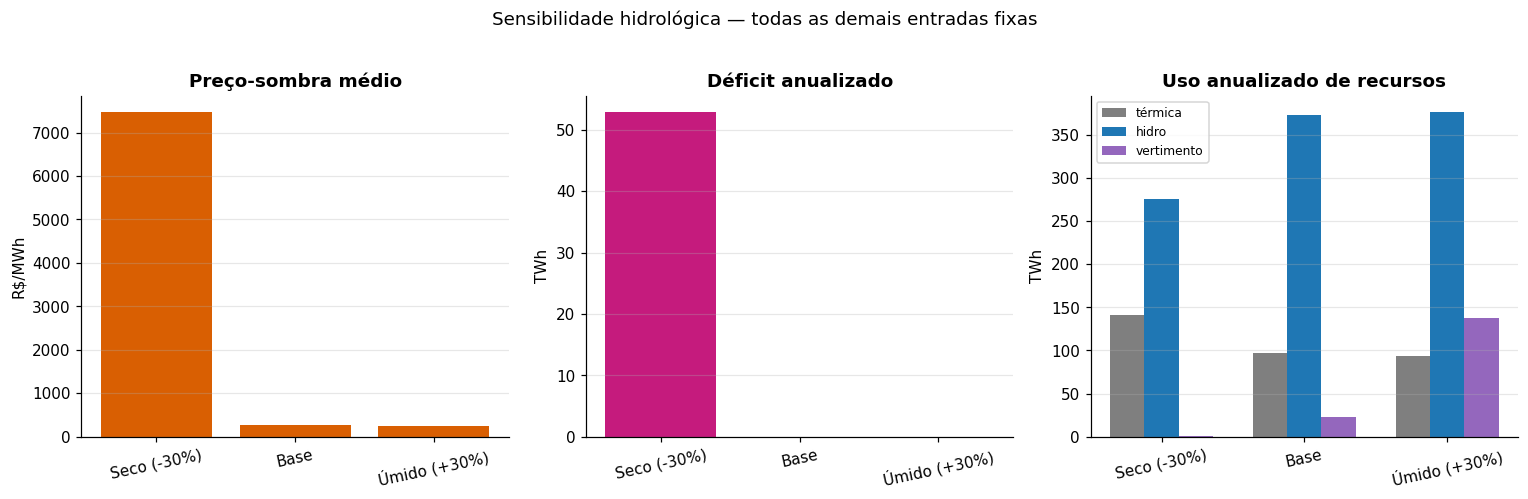

    scenario  inflow_scale  lambda_mean_RS_MWh  thermal_TWh_annualized  hydro_TWh_annualized  spill_TWh_annualized  solar_curt_TWh_annualized  wind_curt_TWh_annualized  deficit_TWh_annualized  reservoir_balance_max_abs_MWh  cyclic_gap_max_abs_MWh
 Seco (-30%)           0.7           7474.2608                141.5587              276.0214                0.8923                        0.0                       0.0                 52.9253                            0.0                     0.0
        Base           1.0            277.0407                 97.5433              372.9621               22.6289                        0.0                       0.0                  0.0000                            0.0                     0.0
Úmido (+30%)           1.3            254.5063                 93.9356              376.5699              137.6986                        0.0                       0.0                  0.0000                            0.0                     0.0


In [7]:
hydrology = load_tab("hydrology_sensitivity.csv")
if hydrology is None or hydrology.empty:
    print("hydrology_sensitivity.csv não encontrado — rode o notebook 07.")
else:
    order = ["Seco (-30%)", "Base", "Úmido (+30%)"]
    hydrology["scenario"] = pd.Categorical(hydrology["scenario"], order, ordered=True)
    hydrology = hydrology.sort_values("scenario").reset_index(drop=True)
    labels = hydrology["scenario"].astype(str).tolist()
    x = np.arange(len(labels))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
    axes[0].bar(x, hydrology["lambda_mean_RS_MWh"], color="#d95f02")
    axes[0].set_title("Preço-sombra médio")
    axes[0].set_ylabel("R$/MWh")
    axes[1].bar(x, hydrology["deficit_TWh_annualized"], color="#c51b7d")
    axes[1].set_title("Déficit anualizado")
    axes[1].set_ylabel("TWh")
    width = 0.24
    for shift, column, label, color in [
        (-width, "thermal_TWh_annualized", "térmica", "#7f7f7f"),
        (0.0, "hydro_TWh_annualized", "hidro", "#1f77b4"),
        (width, "spill_TWh_annualized", "vertimento", "#9467bd"),
    ]:
        axes[2].bar(x + shift, hydrology[column], width, label=label, color=color)
    axes[2].set_title("Uso anualizado de recursos")
    axes[2].set_ylabel("TWh")
    axes[2].legend(fontsize=8)
    for ax in axes:
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=12)
        ax.grid(axis="y", alpha=0.3)
    fig.suptitle("Sensibilidade hidrológica — todas as demais entradas fixas", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rel_hydrology_sensitivity.png", bbox_inches="tight")
    plt.show()
    print(hydrology.round(4).to_string(index=False))


## 7. Laboratório de dois produtores — ponte entre mecanismo e campo médio

O incumbente mantém $K_1$ e o entrante cresce segundo $K_2=\kappa K_1$. A entrada
altera o clearing que determina a receita de ambos. A figura separa **receita
capturada por MWh**, lucro anual e curtailment — objetos que não devem ser
confundidos. O primeiro painel divide a receita pela energia entregue. A queda da
receita capturada corrói o lucro do incumbente, enquanto
o entrante ganha escala apenas até o ponto em que a perda de valor e o custo da
capacidade passam a dominar. Como o curtailment fica praticamente nulo, essa perda
de rentabilidade não é explicada por corte de energia.


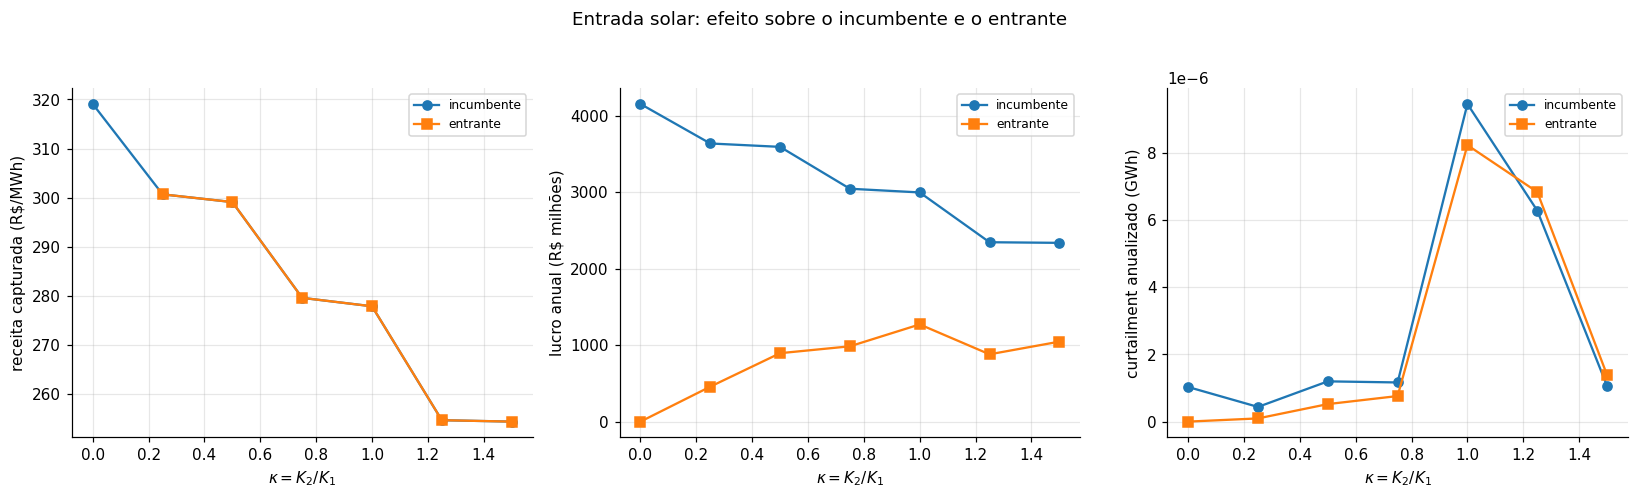

In [8]:
finite = load_tab("finite_two_player_sensitivity.csv")
if finite is None or finite.empty:
    print("finite_two_player_sensitivity.csv não encontrado — rode o notebook 07.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    axes[0].plot(finite["kappa"], finite["captured_1_RS_MWh"], marker="o", label="incumbente")
    axes[0].plot(finite["kappa"], finite["captured_2_RS_MWh"], marker="s", label="entrante")
    axes[0].set_ylabel("receita capturada (R$/MWh)")
    axes[1].plot(finite["kappa"], finite["profit_1_RS"] / 1e6, marker="o", label="incumbente")
    axes[1].plot(finite["kappa"], finite["profit_2_RS"] / 1e6, marker="s", label="entrante")
    axes[1].set_ylabel("lucro anual (R$ milhões)")
    axes[2].plot(finite["kappa"], finite["curtailment_1_MWh"] / 1e3, marker="o", label="incumbente")
    axes[2].plot(finite["kappa"], finite["curtailment_2_MWh"] / 1e3, marker="s", label="entrante")
    axes[2].set_ylabel("curtailment anualizado (GWh)")
    for ax in axes:
        ax.set_xlabel(r"$\kappa=K_2/K_1$"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle("Entrada solar: efeito sobre o incumbente e o entrante", y=1.02)
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_finite_two_player.png", bbox_inches="tight")
    plt.show()


## 8. Benchmark estático — resíduo verdadeiro versus passo relaxado

A figura separa duas coisas que não podem ser confundidas. O **passo**
$\lVert m^{n+1}-m^n\rVert$ mede quanto a rotina se moveu; o **resíduo**
$\lVert BR(R(m^n))-m^n\rVert$ mede a distância ao ponto fixo. Como o primeiro é
multiplicado pela relaxação, somente o segundo participa do certificado.

O benchmark mantém localização fixa e representa uma escolha contínua de
capacidade. O MFG dinâmico completo aparece nas seções finais.


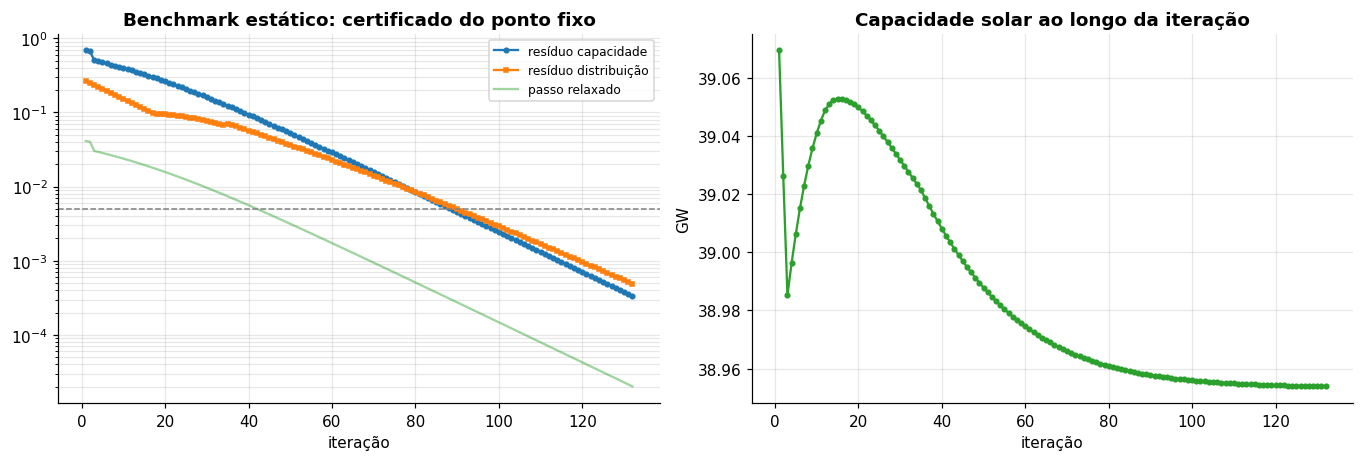

 it  K_total_GW  residual_C  residual_m   step_C
130   38.953917    0.000381    0.000546 0.000023
131   38.953891    0.000358    0.000516 0.000022
132   38.953867    0.000337    0.000488 0.000020


In [9]:
hist = load_tab("mfg_convergence_history.csv")
if hist is None or hist.empty:
    print("Histórico do benchmark não encontrado — rode o notebook 07 antes.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
    axes[0].semilogy(hist["it"], hist["residual_C"], marker="o", ms=3,
                     label="resíduo capacidade")
    axes[0].semilogy(hist["it"], hist["residual_m"], marker="s", ms=3,
                     label="resíduo distribuição")
    axes[0].semilogy(hist["it"], hist["step_C"], alpha=0.45,
                     label="passo relaxado")
    axes[0].axhline(5e-3, ls="--", c="grey", lw=1)
    axes[0].set_title("Benchmark estático: certificado do ponto fixo")
    axes[0].set_xlabel("iteração"); axes[0].grid(alpha=0.3, which="both")
    axes[0].legend(fontsize=8)
    axes[1].plot(hist["it"], hist["K_total_GW"], marker="o", ms=3, color="#2ca02c")
    axes[1].set_title("Capacidade solar ao longo da iteração")
    axes[1].set_xlabel("iteração"); axes[1].set_ylabel("GW"); axes[1].grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_mfg_convergencia.png", bbox_inches="tight")
    plt.show()
    print(hist[["it", "K_total_GW", "residual_C", "residual_m", "step_C"]]
          .tail(3).to_string(index=False))


## 9. Mercado (privado) × ótimo social — o principal resultado econômico

O planejador social é resolvido **de forma independente** do equilíbrio privado (não
é consequência dele) e com total livre, mas sujeito ao limite regional
$K_\ell\leq 3K^{obs}_\ell$. A comparação revela se a entrada privada é excessiva ou
insuficiente, e onde. Cada agente infinitesimal toma o preço como dado e não
internaliza o efeito da própria entrada sobre preço, congestionamento e curtailment;
o planejador coordena esses efeitos. *(Apoia a §"Ótimo social × equilíbrio privado".)*

> **Extensão futura — contratos.** A receita não-spot está resumida hoje em um único
> `premium` calibrado. Um estudo futuro deve representar contratos explicitamente
> (volume, preço, prazo, perfil de entrega, penalidades) para separar hedge
> contratual, exposição ao PLD e receita do preço-sombra.


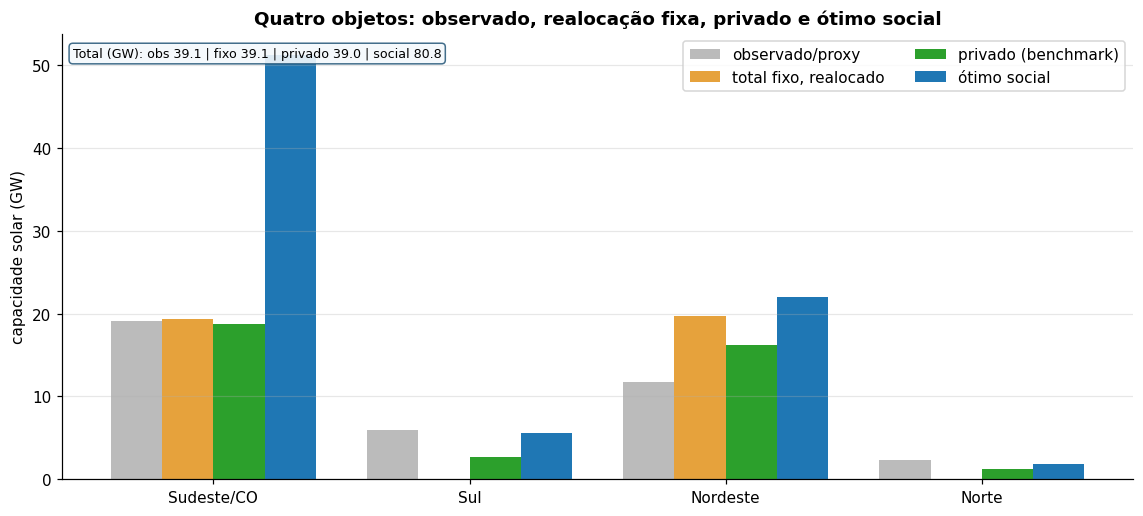

  loc  K_obs_GW  K_fixed_budget_GW  K_mfg_private_GW  K_social_GW  private_minus_social_GW
   SE    19.077             19.327            18.749       51.234                  -32.486
    S     5.919              0.000             2.698        5.568                   -2.870
   NE    11.789             19.742            16.234       22.058                   -5.824
    N     2.284              0.000             1.273        1.904                   -0.630
TOTAL    39.069             39.069            38.954       80.764                  -41.810


In [10]:

comp = load_tab("private_vs_social_capacity.csv")
if comp is None:
    print("Tabela private_vs_social_capacity.csv não encontrada — rode o notebook 07.")
else:
    plot_c = comp[comp["loc"] != "TOTAL"].copy()
    plot_c = plot_c.set_index("loc").reindex(SUBSYS_ORDER).reset_index()
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    idx = np.arange(len(plot_c)); w = 0.20
    ax.bar(idx - 1.5*w, plot_c["K_obs_GW"], w,
           label="observado/proxy", color="#bbbbbb")
    ax.bar(idx - 0.5*w, plot_c["K_fixed_budget_GW"], w,
           label="total fixo, realocado", color="#e6a23c")
    ax.bar(idx + 0.5*w, plot_c["K_mfg_private_GW"], w,
           label="privado (benchmark)", color="#2ca02c")
    ax.bar(idx + 1.5*w, plot_c["K_social_GW"], w,
           label="ótimo social", color="#1f77b4")
    ax.set_xticks(idx); ax.set_xticklabels([SUB_LABEL[s] for s in plot_c["loc"]])
    ax.set_ylabel("capacidade solar (GW)")
    ax.set_title("Quatro objetos: observado, realocação fixa, privado e ótimo social")
    ax.grid(axis="y", alpha=0.3); ax.legend(ncol=2)
    tot = comp[comp["loc"] == "TOTAL"]
    if not tot.empty:
        t = tot.iloc[0]
        ax.text(0.01, 0.97,
                f'Total (GW): obs {t["K_obs_GW"]:.1f} | fixo {t["K_fixed_budget_GW"]:.1f} | '
                f'privado {t["K_mfg_private_GW"]:.1f} | social {t["K_social_GW"]:.1f}',
                transform=ax.transAxes, fontsize=8.3, va="top",
                bbox=dict(boxstyle="round", fc="#f4f9fc", ec="#2f5f7f", alpha=0.9))
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rel_mercado_vs_social.png", bbox_inches="tight")
    plt.show()
    print(comp.round(3).to_string(index=False))


## 10. Topologia do intercâmbio — o hub $I$

O clearing locacional usa quatro nós com carga/geração e um **nó contábil de
intercâmbio $I$**. A topologia é $I\leftrightarrow\{N, NE, SE\}$,
$NE\leftrightarrow SE$ e $SE\leftrightarrow S$; **não** existem arestas diretas
$N\leftrightarrow NE$ nem $N\leftrightarrow SE$. O nó
$I$ não tem carga nem geração: sua soma algébrica de fluxos é zero (não cria nem
destrói energia). A ligação direta NE–SE é a quinta aresta usada tanto no clearing
quanto no planejador. *(Apoia a seção "Rede e variáveis de decisão" do
`report_v2.typ`; implementação: `EDGES`/`FMAX` no notebook 07.)*


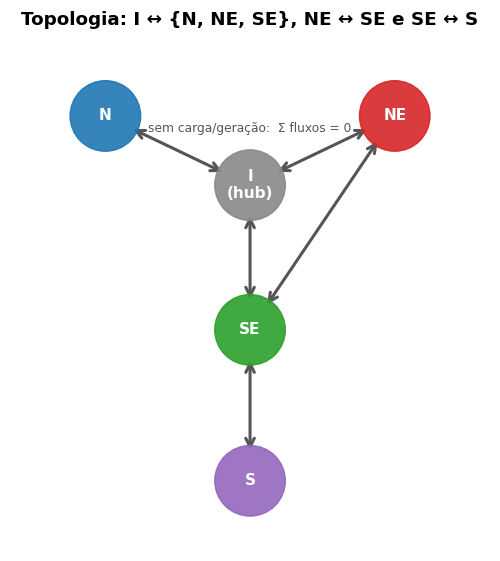

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
pos = {"I": (0.0, 0.0), "SE": (0.0, -1.15), "NE": (1.15, 0.55),
       "N": (-1.15, 0.55), "S": (0.0, -2.35)}
edges = [("I", "SE"), ("I", "NE"), ("I", "N"), ("NE", "SE"), ("SE", "S")]
for a, b in edges:
    (x0, y0), (x1, y1) = pos[a], pos[b]
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="<->",
                 mutation_scale=14, lw=2, color="#555555", shrinkA=20, shrinkB=20))
for name, (x, y) in pos.items():
    is_hub = name == "I"
    col = "#888888" if is_hub else SUB_COLOR.get(name, "#333")
    ax.add_patch(Circle((x, y), 0.28, color=col, alpha=0.9, zorder=3))
    lbl = "I\n(hub)" if is_hub else name
    ax.text(x, y, lbl, ha="center", va="center", color="white", fontweight="bold",
            fontsize=10, zorder=4)
ax.text(0, 0.42, "sem carga/geração:  Σ fluxos = 0", ha="center", fontsize=8, color="#555")
ax.set_xlim(-1.9, 1.9); ax.set_ylim(-2.9, 1.2); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Topologia: I ↔ {N, NE, SE}, NE ↔ SE e SE ↔ S", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "rel_topologia_intercambio.png", bbox_inches="tight")
plt.show()


## 11. Dias representativos — o que os clusters representam

O número de dias típicos é escolhido automaticamente (silhueta + cobertura de
estação e regime de calendário), e cada cluster é representado pelo **dia real mais
próximo (medoide)**. A figura mostra o peso anualizado de cada dia típico, colorido
por estação, com o regime de calendário (útil / fim de semana / feriado /
férias-fim de ano) anotado. A segunda figura mede a homogeneidade: distância RMS
de cada dia ao medoide nas mesmas variáveis operacionais padronizadas usadas pelo
clustering. D04 é o bloco mais coeso em média, embora contenha poucos dias distantes;
D01 tem a cauda superior mais dispersa. O conjunto indica que os medoides representam
bem o centro dos regimes, mas não eliminam a necessidade de sensibilidades para dias
extremos. *(Apoia a seção "Dias representativos" do `report_v2.typ`;
implementação e tabela: seção 3 do notebook 07.)*


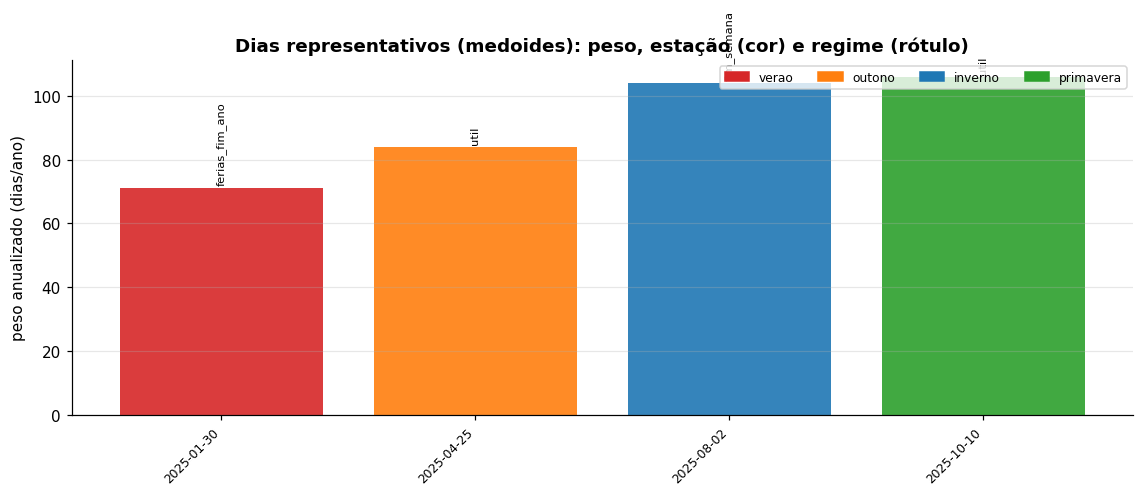

block       date    season       day_type  weight_days                   cluster_profile  distance_mean_rms  distance_p90_rms  distance_max_rms
  D01 2025-01-30     verao ferias_fim_ano         71.0 verao (93%); ferias_fim_ano (54%)           0.899275          1.252283          1.544349
  D02 2025-04-25    outono           util         84.0          outono (99%); util (69%)           0.775389          1.015101          1.322704
  D03 2025-08-02   inverno     fim_semana        104.0   inverno (78%); fim_semana (35%)           0.799203          1.016340          1.211193
  D04 2025-10-10 primavera           util        106.0       primavera (73%); util (84%)           0.696546          1.051677          1.543760


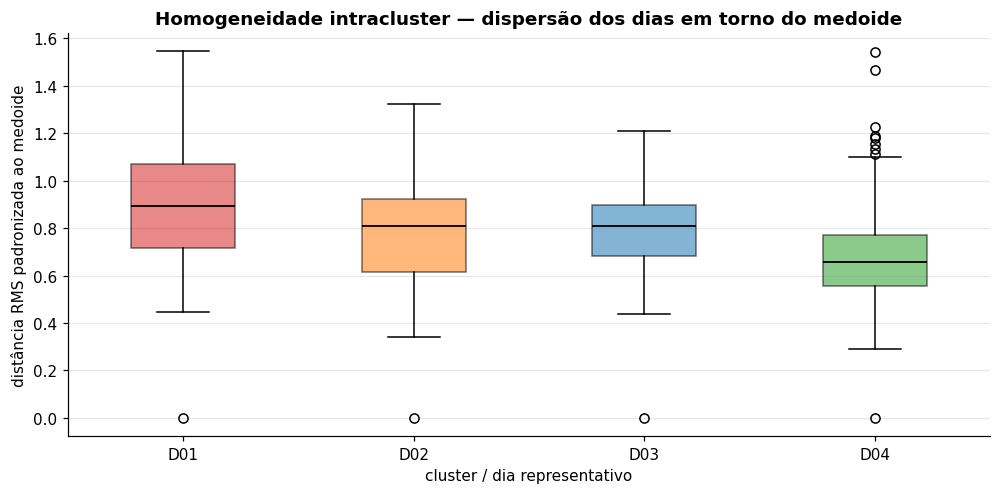

In [12]:
rep = load_tab("representative_days.csv")
hom = load_tab("representative_days_homogeneity.csv")
if rep is None or rep.empty:
    print("representative_days.csv não encontrado — rode o notebook 07.")
else:
    season_color = {"verao": "#d62728", "outono": "#ff7f0e",
                    "inverno": "#1f77b4", "primavera": "#2ca02c"}
    rep = rep.sort_values("date").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(10.5, 4.6))
    x = np.arange(len(rep))
    colors = [season_color.get(s, "#888") for s in rep["season"]]
    ax.bar(x, rep["weight_days"], color=colors, alpha=0.9)
    for xi, (_, r) in zip(x, rep.iterrows()):
        ax.text(xi, r["weight_days"] + 1, str(r["day_type"]), ha="center",
                va="bottom", fontsize=7.5, rotation=90)
    ax.set_xticks(x); ax.set_xticklabels(rep["date"], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("peso anualizado (dias/ano)")
    ax.set_title("Dias representativos (medoides): peso, estação (cor) e regime (rótulo)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in season_color.values()]
    ax.legend(handles, list(season_color.keys()), fontsize=8, ncol=4, loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rel_dias_representativos.png", bbox_inches="tight")
    plt.show()
    print(rep[["block", "date", "season", "day_type", "weight_days", "cluster_profile",
               "distance_mean_rms", "distance_p90_rms", "distance_max_rms"]].to_string(index=False))
    if hom is not None and not hom.empty:
        order = rep["block"].tolist()
        values = [hom.loc[hom["block"] == block, "distance_to_medoid_rms"].to_numpy()
                  for block in order]
        fig, ax = plt.subplots(figsize=(9.2, 4.6))
        bp = ax.boxplot(values, tick_labels=order, patch_artist=True, showfliers=True,
                        medianprops={"color": "black", "lw": 1.2})
        for box, block in zip(bp["boxes"], order):
            season = rep.loc[rep["block"] == block, "season"].iloc[0]
            box.set(facecolor=season_color.get(season, "#888"), alpha=0.55)
        ax.set_ylabel("distância RMS padronizada ao medoide")
        ax.set_xlabel("cluster / dia representativo")
        ax.set_title("Homogeneidade intracluster — dispersão dos dias em torno do medoide")
        ax.grid(axis="y", alpha=0.3)
        fig.tight_layout()
        fig.savefig(FIG_DIR / "rel_homogeneidade_clusters.png", bbox_inches="tight")
        plt.show()


## 12. MFG dinâmico — Bellman, forward, clearing e ponto fixo

Agora localização e capacidade pertencem à mesma decisão. A trajetória de
distribuições gera capacidade e preços em cada estágio; o Bellman gera uma política;
e a equação forward deve reproduzir a própria trajetória usada no clearing.

O painel da esquerda mostra os resíduos **antes** da relaxação. O da direita mostra
como a capacidade locacional evolui ao longo do horizonte. Se o certificado final
for falso, a leitura correta é “aproximação iterativa”, não “equilíbrio convergido”.


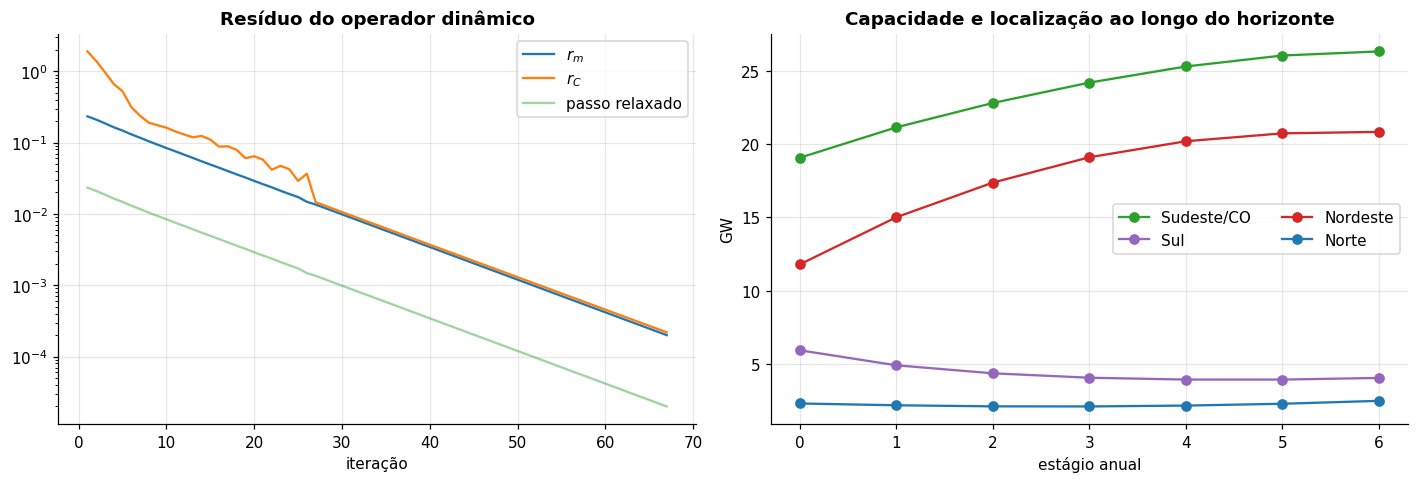

 it  residual_m  residual_C   step_m  K_initial_GW  K_terminal_GW
 65    0.000246    0.000269 0.000025     39.069292      53.684340
 66    0.000222    0.000243 0.000022     39.069292      53.684910
 67    0.000200    0.000219 0.000020     39.069292      53.685422


In [13]:
dyn_hist = load_tab("dynamic_mfg_convergence.csv")
dyn_path = load_tab("dynamic_mfg_path.csv")
if dyn_hist is None or dyn_path is None or dyn_hist.empty or dyn_path.empty:
    print("Tabelas do MFG dinâmico não encontradas — rode a Seção 10 do notebook 07.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].semilogy(dyn_hist["it"], dyn_hist["residual_m"], label=r"$r_m$")
    axes[0].semilogy(dyn_hist["it"], dyn_hist["residual_C"], label=r"$r_C$")
    axes[0].semilogy(dyn_hist["it"], dyn_hist["step_m"], alpha=0.45,
                     label="passo relaxado")
    axes[0].set_title("Resíduo do operador dinâmico")
    axes[0].set_xlabel("iteração"); axes[0].grid(alpha=0.3); axes[0].legend()
    for loc in SUBSYS_ORDER:
        subset = dyn_path[dyn_path["loc"] == loc]
        axes[1].plot(subset["stage"], subset["capacity_MW"] / 1000,
                     marker="o", label=SUB_LABEL[loc], color=SUB_COLOR[loc])
    axes[1].set_title("Capacidade e localização ao longo do horizonte")
    axes[1].set_xlabel("estágio anual"); axes[1].set_ylabel("GW")
    axes[1].grid(alpha=0.3); axes[1].legend(ncol=2)
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_dynamic_mfg_fixed_point.png", bbox_inches="tight")
    plt.show()
    print(dyn_hist.tail(3).to_string(index=False))


## 13. Trajetória da distribuição de campo médio

A capacidade agregada não mostra como a massa está espalhada entre estados. Cada
mapa de calor abaixo soma os dois tipos e apresenta
$\sum_\theta m_t(\ell,\theta,b)$: o eixo horizontal é o estágio, o vertical é a
capacidade individual do bin e a cor é a fração **incondicional da população**
naquele estado. A soma dos quatro mapas em cada estágio é um. A figura de massas
locacionais, por sua vez, integra todos os bins e tipos e torna a realocação
geográfica visível sem escolher trajetórias individuais artificiais.

A massa não converge toda para uma única região porque o destino mais rentável muda
quando a própria população se desloca. Canibalização reduz a receita local, a
penalidade de concentração cresce com a massa, mudança e ajuste têm custo, e os
tipos `high` e `low` não avaliam as ações da mesma forma. Com $\tau>0$, alternativas
de valor próximo também recebem probabilidade positiva. A dispersão observada é,
portanto, parte da construção econômica do modelo, não um ruído do gráfico.


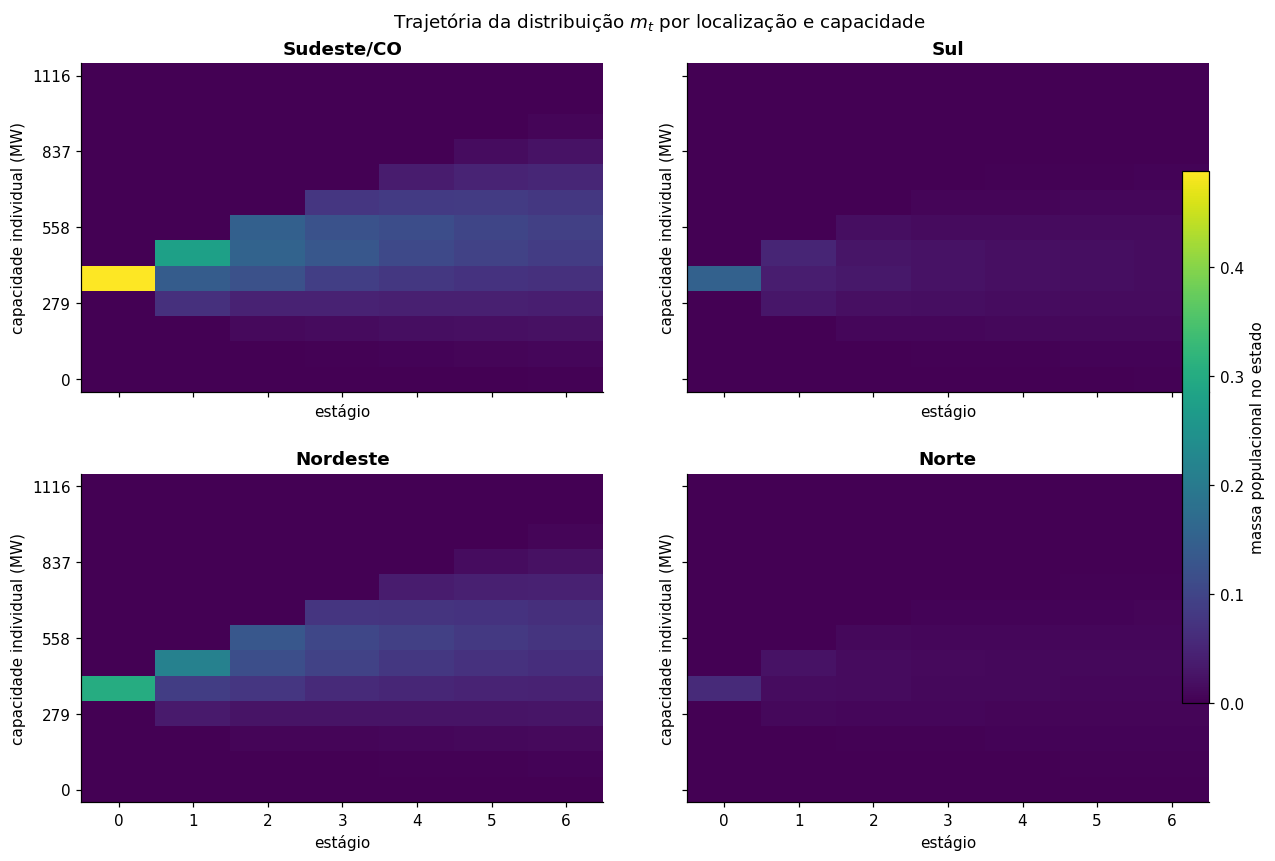

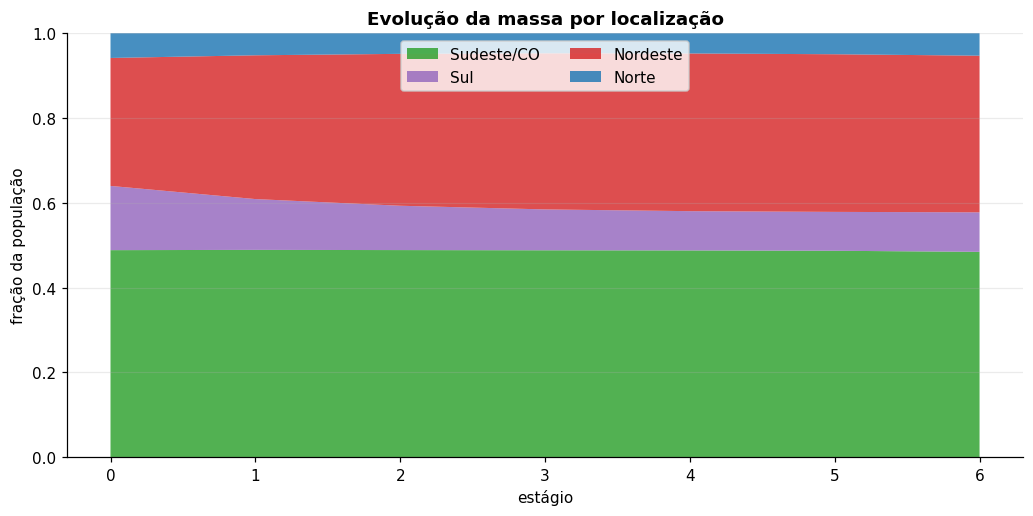

Erro máximo de conservação de massa: 3.33e-16


In [14]:
dyn_dist = load_tab("dynamic_mfg_distribution.csv")
dyn_path = load_tab("dynamic_mfg_path.csv")
if dyn_dist is None or dyn_path is None or dyn_dist.empty or dyn_path.empty:
    print("Distribuição dinâmica não encontrada — rode o notebook 07.")
else:
    agg = (dyn_dist.groupby(["stage", "loc", "bin", "K_agent_MW"], as_index=False)
           ["mass"].sum())
    vmax = float(agg["mass"].max())
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8), sharex=True, sharey=True)
    image = None
    for ax, loc in zip(axes.ravel(), SUBSYS_ORDER):
        subset = agg[agg["loc"] == loc]
        matrix = (subset.pivot(index="bin", columns="stage", values="mass")
                  .fillna(0).sort_index())
        image = ax.imshow(matrix.to_numpy(), aspect="auto", origin="lower",
                          vmin=0, vmax=vmax, cmap="viridis")
        ax.set_title(SUB_LABEL[loc])
        ax.set_xlabel("estágio")
        ax.set_ylabel("capacidade individual (MW)")
        ax.set_xticks(range(len(matrix.columns)))
        ax.set_xticklabels(matrix.columns.astype(int))
        yticks = np.arange(0, len(matrix.index), 3)
        capacities = (subset.drop_duplicates("bin").set_index("bin")
                      ["K_agent_MW"].reindex(matrix.index))
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{capacities.iloc[y]:.0f}" for y in yticks])
    fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.03,
                 label="massa populacional no estado")
    fig.suptitle("Trajetória da distribuição $m_t$ por localização e capacidade", y=0.98)
    fig.subplots_adjust(left=0.08, right=0.90, bottom=0.08, top=0.92,
                        wspace=0.16, hspace=0.25)
    fig.savefig(FIG_DIR / "rel_dynamic_mfg_distribution_trajectory.png",
                bbox_inches="tight")
    plt.show()

    loc_mass = (dyn_path.pivot(index="stage", columns="loc", values="mass")
                .reindex(columns=SUBSYS_ORDER).fillna(0))
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    ax.stackplot(loc_mass.index,
                 *[loc_mass[loc].to_numpy() for loc in SUBSYS_ORDER],
                 labels=[SUB_LABEL[loc] for loc in SUBSYS_ORDER],
                 colors=[SUB_COLOR[loc] for loc in SUBSYS_ORDER], alpha=0.82)
    ax.set_ylim(0, 1)
    ax.set_xlabel("estágio"); ax.set_ylabel("fração da população")
    ax.set_title("Evolução da massa por localização")
    ax.grid(axis="y", alpha=0.25); ax.legend(ncol=2, loc="upper center")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rel_dynamic_mfg_location_mass.png", bbox_inches="tight")
    plt.show()
    mass_check = loc_mass.sum(axis=1)
    print(f"Erro máximo de conservação de massa: {(mass_check - 1).abs().max():.2e}")



## 14. Política dinâmica e trajetórias modais

Com $\tau>0$, a política é probabilística por construção. A primeira figura lê
dois momentos da política no estágio inicial: na linha superior, a probabilidade
de mudar de subsistema; na inferior, o ajuste esperado de capacidade em MW. Cada
coluna corresponde a um tipo de produtividade e cada célula a um par
localização-bin. Assim, “ficar no mesmo lugar” e “manter a mesma capacidade” não
são confundidos.

A figura de trajetórias segue apenas a ação modal de agentes representativos. Ela
é uma interpretação microeconômica auxiliar: o objeto agregado correto continua
sendo a distribuição forward, pois a trajetória modal descarta as probabilidades
das demais ações.


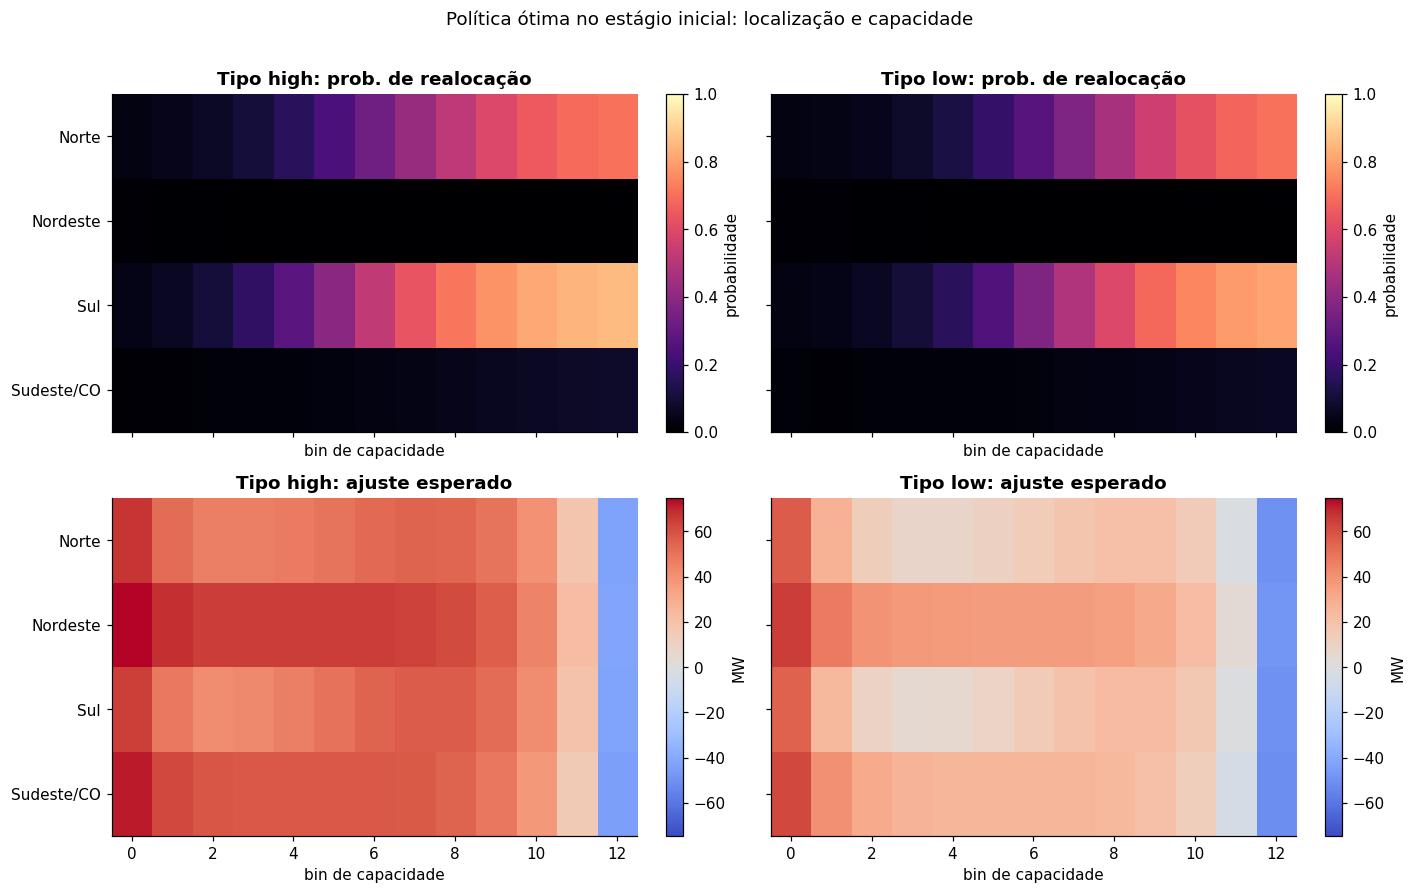

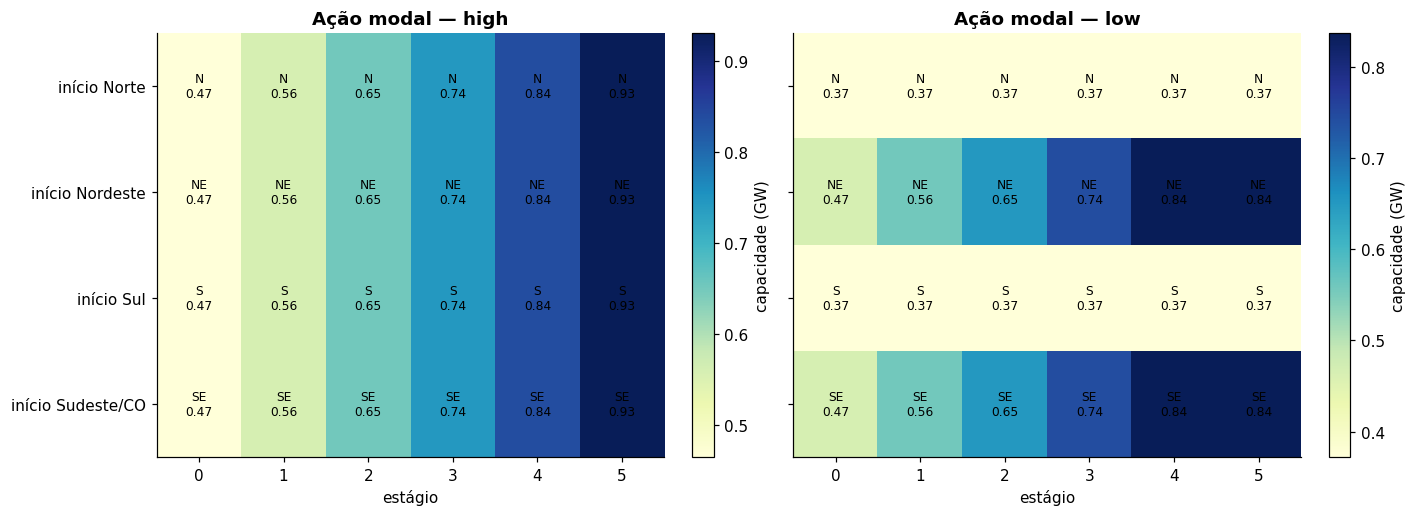

In [15]:

dyn_policy = load_tab("dynamic_mfg_policy_summary.csv")
dyn_modal = load_tab("dynamic_mfg_modal_paths.csv")
if dyn_policy is None or dyn_modal is None or dyn_policy.empty or dyn_modal.empty:
    print("Política dinâmica não encontrada — rode o notebook 07.")
else:
    types = [t for t in ["high", "low"] if t in set(dyn_policy["type"])]
    fig, axes = plt.subplots(2, len(types), figsize=(13, 8), squeeze=False,
                             sharex="col", sharey="row")
    max_adjust = float(dyn_policy.loc[dyn_policy["stage"] == 0,
                                      "expected_delta_MW"].abs().max())
    for col, agent_type in enumerate(types):
        subset = dyn_policy[(dyn_policy["stage"] == 0)
                            & (dyn_policy["type"] == agent_type)]
        relocation = (subset.pivot(index="loc_current", columns="bin_current",
                                   values="relocation_probability")
                      .reindex(SUBSYS_ORDER))
        adjustment = (subset.pivot(index="loc_current", columns="bin_current",
                                   values="expected_delta_MW")
                      .reindex(SUBSYS_ORDER))
        image_top = axes[0, col].imshow(relocation.to_numpy(), aspect="auto",
                                        origin="lower", vmin=0, vmax=1, cmap="magma")
        image_bottom = axes[1, col].imshow(adjustment.to_numpy(), aspect="auto",
                                           origin="lower", vmin=-max_adjust,
                                           vmax=max_adjust, cmap="coolwarm")
        for row in range(2):
            axes[row, col].set_yticks(range(len(SUBSYS_ORDER)))
            axes[row, col].set_yticklabels([SUB_LABEL[loc] for loc in SUBSYS_ORDER])
            axes[row, col].set_xlabel("bin de capacidade")
        axes[0, col].set_title(f"Tipo {agent_type}: prob. de realocação")
        axes[1, col].set_title(f"Tipo {agent_type}: ajuste esperado")
        fig.colorbar(image_top, ax=axes[0, col], fraction=0.046,
                     label="probabilidade")
        fig.colorbar(image_bottom, ax=axes[1, col], fraction=0.046,
                     label="MW")
    fig.suptitle("Política ótima no estágio inicial: localização e capacidade", y=1.01)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rel_dynamic_mfg_policy.png", bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, len(types), figsize=(13, 4.8), sharey=True, squeeze=False)
    for col, agent_type in enumerate(types):
        subset = dyn_modal[dyn_modal["type"] == agent_type]
        cap = (subset.assign(K_next_GW=subset["K_next_MW"] / 1000)
               .pivot(index="initial_loc", columns="stage", values="K_next_GW")
               .reindex(SUBSYS_ORDER))
        loc = (subset.pivot(index="initial_loc", columns="stage", values="loc_next")
               .reindex(SUBSYS_ORDER))
        image = axes[0, col].imshow(cap.to_numpy(), aspect="auto", origin="lower",
                                    cmap="YlGnBu")
        for yi in range(cap.shape[0]):
            for xi in range(cap.shape[1]):
                axes[0, col].text(xi, yi, f"{loc.iloc[yi, xi]}\n{cap.iloc[yi, xi]:.2f}",
                                  ha="center", va="center", fontsize=8)
        axes[0, col].set_yticks(range(len(SUBSYS_ORDER)))
        axes[0, col].set_yticklabels([f"início {SUB_LABEL[s]}" for s in SUBSYS_ORDER])
        axes[0, col].set_xlabel("estágio"); axes[0, col].set_title(f"Ação modal — {agent_type}")
        fig.colorbar(image, ax=axes[0, col], fraction=0.046, label="capacidade (GW)")
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_dynamic_mfg_modal_paths.png",
                                    bbox_inches="tight")
    plt.show()



## 15. Diagnósticos adicionais — $\Lambda'$, termos quadráticos, $\gamma_r$ e vertimento

Esta seção transforma em figuras as tabelas geradas pelo notebook 07 e registra a
leitura econômica que deve acompanhar cada painel.
`lambda_prime_sensitivity.csv` contém a diferença finita de +100 MW de carga;
`dispatch_quadratic_terms_sensitivity.csv` zera cada termo quadrático;
`gamma_r_sensitivity.csv` varia somente $\gamma_r$; e
`spill_diagnostic_by_region.csv` decompõe a afluência em turbinamento e vertimento.
No Sul, a secante de 100 MW chama atenção porque atravessa uma quina: D02 passa a
saturar SE--S nas 24 horas e aciona um bloco térmico mais caro. Passos de 1 a 10 MW
ficam perto de 0,0011 R$/MWh por MW; o salto aparece entre 60 e 65 MW e é auditado
em `lambda_prime_south_step_sensitivity.csv`. Os termos quadráticos quase não mudam
os totais anuais, mas mudam a forma horária; em particular, $\gamma_r=0{,}002$ reduz
a rampa RMS em cerca de 55% frente a $\gamma_r=0$, com efeito quase nulo no preço
médio e na energia anual.
As equações e a interpretação econômica aparecem nas seções homônimas do
`report_v2.typ` e nas seções 4.5.1/4.6 do notebook 07.


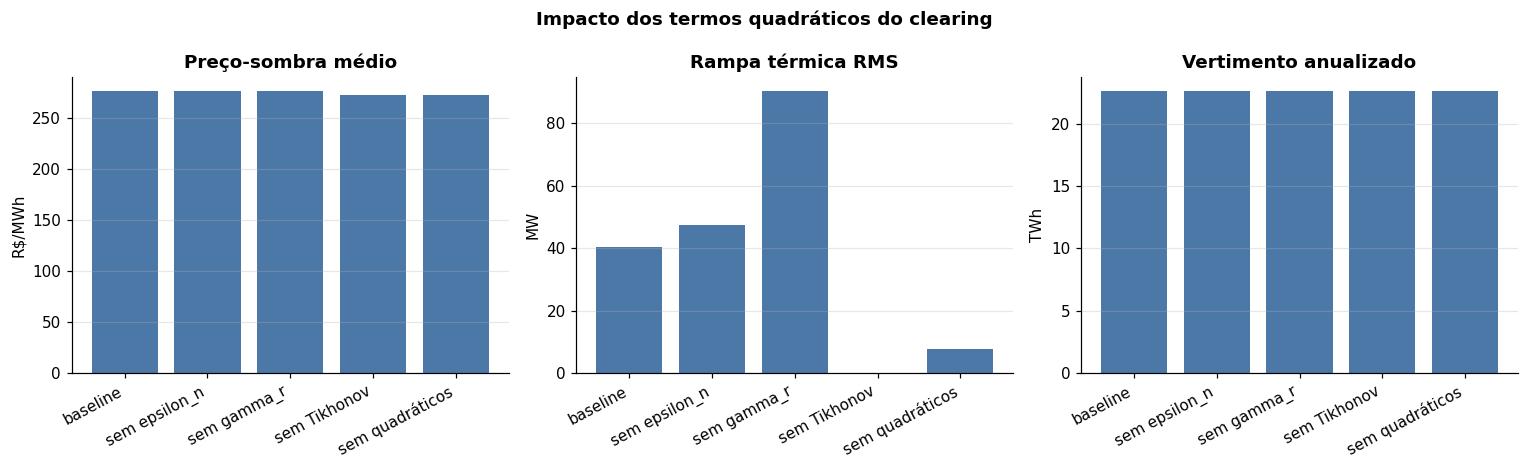

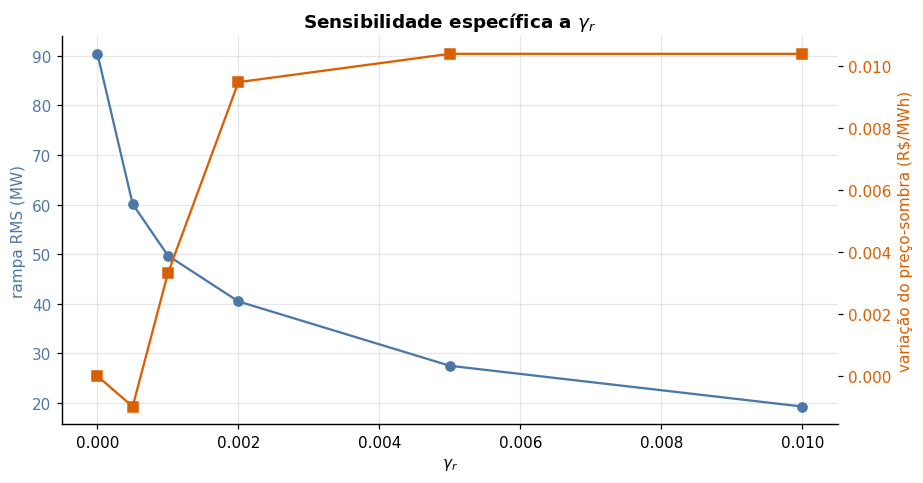

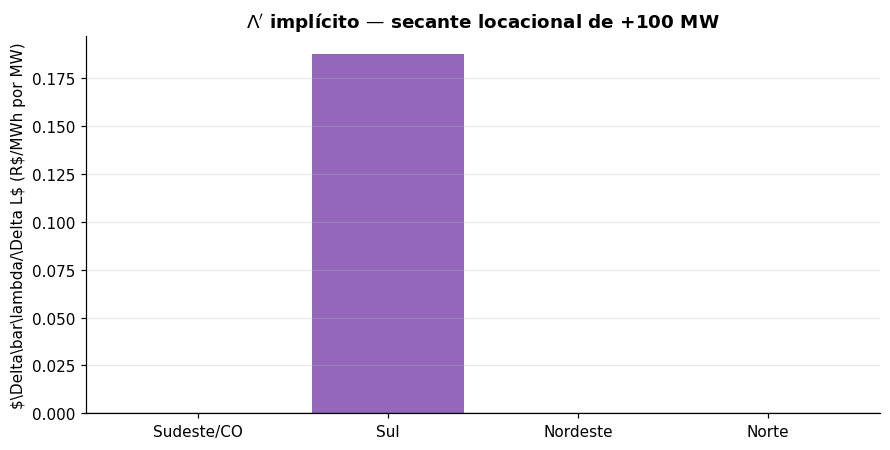

Auditoria do tamanho do passo no Sul:


,delta_load_MW,south_secant_RS_MWh_per_MW,D02_lambda_change_RS_MWh,D02_SE_S_saturated_hours_baseline,D02_SE_S_saturated_hours_perturbed,D02_additional_medium_high_thermal_MWh_day
0,1.0,0.001127,0.003572,21,21,0.000000
1,5.0,0.001127,0.017876,21,21,0.000013
2,10.0,0.001160,0.037164,21,21,0.000019
3,25.0,0.001380,0.117820,21,22,0.000049
4,50.0,0.001451,0.254730,21,22,0.000140
5,60.0,0.001463,0.309653,21,22,0.000174
6,65.0,0.287139,81.022018,21,24,7.421454
7,70.0,0.267185,81.185480,21,24,127.422269
8,75.0,0.249552,81.238485,21,24,247.422507
9,80.0,0.234095,81.281495,21,24,367.421825


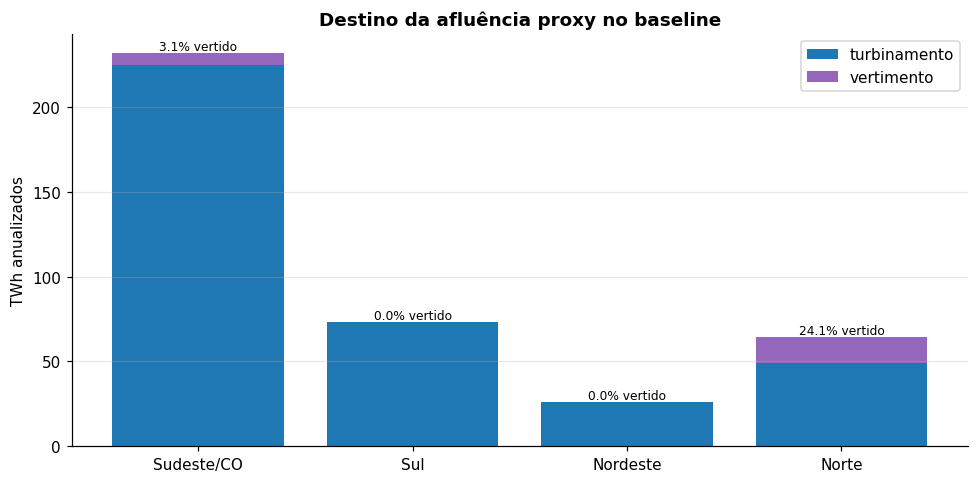

In [16]:
quad = load_tab("dispatch_quadratic_terms_sensitivity.csv")
gamma_r = load_tab("gamma_r_sensitivity.csv")
lam_prime = load_tab("lambda_prime_sensitivity.csv")
south_lambda_steps = load_tab("lambda_prime_south_step_sensitivity.csv")
spill_diag = load_tab("spill_diagnostic_by_region.csv")

if quad is not None and not quad.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
    x = np.arange(len(quad))
    for ax, col, title, ylabel in [
        (axes[0], "lambda_mean_RS_MWh", "Preço-sombra médio", "R$/MWh"),
        (axes[1], "thermal_ramp_rms_MW", "Rampa térmica RMS", "MW"),
        (axes[2], "spill_TWh_annualized", "Vertimento anualizado", "TWh")]:
        ax.bar(x, quad[col], color="#4c78a8")
        ax.set_xticks(x); ax.set_xticklabels(quad["scenario"], rotation=28, ha="right")
        ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(axis="y", alpha=0.3)
    fig.suptitle("Impacto dos termos quadráticos do clearing", fontweight="bold")
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_quadratic_terms_sensitivity.png",
                                    bbox_inches="tight"); plt.show()

if gamma_r is not None and not gamma_r.empty:
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.plot(gamma_r["gamma_r"], gamma_r["thermal_ramp_rms_MW"], marker="o",
            color="#4c78a8", label="rampa térmica RMS")
    ax.set_xlabel(r"$\gamma_r$"); ax.set_ylabel("rampa RMS (MW)", color="#4c78a8")
    ax.tick_params(axis="y", labelcolor="#4c78a8"); ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    lambda_delta = gamma_r["lambda_mean_RS_MWh"] - gamma_r.iloc[0]["lambda_mean_RS_MWh"]
    ax2.plot(gamma_r["gamma_r"], lambda_delta, marker="s",
             color="#d95f02", label="variação do preço-sombra")
    ax2.set_ylabel("variação do preço-sombra (R$/MWh)", color="#d95f02")
    ax2.tick_params(axis="y", labelcolor="#d95f02")
    ax.set_title(r"Sensibilidade específica a $\gamma_r$")
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_gamma_r_sensitivity.png",
                                    bbox_inches="tight"); plt.show()

if lam_prime is not None and not lam_prime.empty:
    plot_lp = lam_prime.set_index("loc").reindex(SUBSYS_ORDER).reset_index()
    fig, ax = plt.subplots(figsize=(8.2, 4.2))
    ax.bar([SUB_LABEL[s] for s in plot_lp["loc"]],
           plot_lp["lambda_prime_RS_MWh_per_MW"],
           color=[SUB_COLOR[s] for s in plot_lp["loc"]])
    ax.axhline(0, color="black", lw=0.8); ax.grid(axis="y", alpha=0.3)
    ax.set_ylabel(r"$\Delta\bar\lambda/\Delta L$ (R$/MWh por MW)")
    ax.set_title(r"$\Lambda'$ implícito — secante locacional de +100 MW")
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_lambda_prime_sensitivity.png",
                                    bbox_inches="tight"); plt.show()
    if south_lambda_steps is not None and not south_lambda_steps.empty:
        print("Auditoria do tamanho do passo no Sul:")
        display(south_lambda_steps.round(6))

if spill_diag is not None and not spill_diag.empty:
    sd = spill_diag.set_index("loc").reindex(SUBSYS_ORDER).reset_index()
    x = np.arange(len(sd))
    hydro = sd["hydro_weighted"] / 1e6
    spill = sd["spill_weighted"] / 1e6
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x, hydro, label="turbinamento", color="#1f77b4")
    ax.bar(x, spill, bottom=hydro, label="vertimento", color="#9467bd")
    for xi, h, v, share in zip(x, hydro, spill, sd["spill_share_inflow"]):
        ax.text(xi, h + v, f"{share:.1%} vertido", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([SUB_LABEL[s] for s in sd["loc"]])
    ax.set_ylabel("TWh anualizados"); ax.set_title("Destino da afluência proxy no baseline")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(); fig.savefig(FIG_DIR / "rel_spill_diagnostic.png",
                                    bbox_inches="tight"); plt.show()



## 16. Síntese — mapa das figuras para a arquitetura conceitual

| Figura | Papel no argumento |
|---|---|
| `rel_cmo_vs_carga_residual.png` | mecanismo empírico da canibalização |
| `rel_cmo_perfil_horario_boxplot.png` | distribuição horária do CMO |
| `rel_curva_pato.png` | flexibilidade e rampa residual nas quatro regiões |
| `rel_homogeneidade_clusters.png` | dispersão intracluster em torno dos medoides |
| `rel_fatores_captura.png` | preço capturado por fonte |
| `rel_reservoir_state.png` | dinâmica $S_{t+1}=S_t+A_t-h_t-v_t$ |
| `rel_hydrology_sensitivity.png` | seco/base/úmido com demais entradas fixas |
| `rel_lambda_prime_sensitivity.png` | secante direcional de 100 MW e auditoria da quina no Sul |
| `rel_quadratic_terms_sensitivity.png` | impacto dos termos quadráticos |
| `rel_gamma_r_sensitivity.png` | sensibilidade específica à penalidade de rampa |
| `rel_spill_diagnostic.png` | decomposição regional da afluência em hidro e vertimento |
| `rel_finite_two_player.png` | incumbente, entrante e canibalização estratégica |
| `rel_mfg_convergencia.png` | benchmark estático e resíduo correto |
| `rel_mercado_vs_social.png` | observado, total fixo, privado e planejador |
| `rel_dynamic_mfg_fixed_point.png` | Bellman + forward + clearing + ponto fixo |
| `rel_dynamic_mfg_distribution_trajectory.png` | trajetória completa de $m_t$ por bin e região |
| `rel_dynamic_mfg_location_mass.png` | realocação da massa entre subsistemas |
| `rel_dynamic_mfg_policy.png` | probabilidades de mudança e ajuste esperado |
| `rel_dynamic_mfg_modal_paths.png` | leitura modal auxiliar da política |

As figuras preservam a separação entre mecanismo, aproximação numérica e
certificação matemática. O modelo não usa pequena variação entre iteradas como
prova de equilíbrio, e as trajetórias modais não substituem a distribuição
probabilística forward.
